# Exploratory Data Analysis

**Inputs:** `data/train.csv`, `data/test.csv`
**Outputs:** charts saved to `outputs/eda/`

In [3]:
#pip install -r ../requirements.txt

In [4]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from wordcloud import WordCloud

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "data").exists() else NB_DIR.parent
DATA_DIR = REPO_ROOT / "data"
OUT_DIR = REPO_ROOT / "outputs" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))

LABEL_NAMES = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
LABEL_PALETTE = {"Bearish": "#d62728", "Bullish": "#2ca02c", "Neutral": "#7f7f7f"}

print("Repo root:", REPO_ROOT)
print("Saving charts to:", OUT_DIR)

Repo root: c:\Users\MartaFeria\Documents\NovaIms\TextMining\Project\repo
Saving charts to: c:\Users\MartaFeria\Documents\NovaIms\TextMining\Project\repo\outputs\eda


In [5]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
print(f"train: {train.shape}  |  test: {test.shape}")
train.head()

train: (9543, 2)  |  test: (2388, 2)


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [6]:
print("train info:")
train.info()
print("\nNulls in train:")
print(train.isna().sum())
print("\nNulls in test:")
print(test.isna().sum())

train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9543 non-null   object
 1   label   9543 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 149.2+ KB

Nulls in train:
text     0
label    0
dtype: int64

Nulls in test:
id      0
text    0
dtype: int64


## Tweet length, token stats, class balance

In [7]:
counts = train["label"].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(2)
class_summary = pd.DataFrame({
    "class": counts.index.map(LABEL_NAMES),
    "count": counts.values,
    "pct": pct.values,
})
class_summary

,class,count,pct
0,Bearish,1442,15.11
1,Bullish,1923,20.15
2,Neutral,6178,64.74


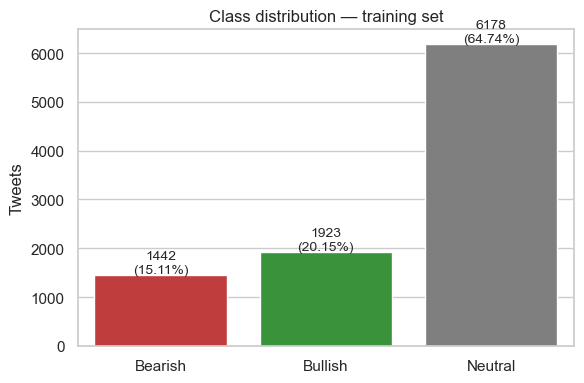

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=class_summary, x="class", y="count",
            hue="class", palette=LABEL_PALETTE, legend=False, ax=ax)
for i, (cnt, p) in enumerate(zip(class_summary["count"], class_summary["pct"])):
    ax.text(i, cnt + 50, f"{cnt}\n({p}%)", ha="center", fontsize=10)
ax.set_title("Class distribution — training set")
ax.set_ylabel("Tweets")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png")
plt.show()

In [9]:
train["char_len"] = train["text"].str.len()
train["token_len"] = train["text"].str.split().str.len()
test["char_len"] = test["text"].str.len()
test["token_len"] = test["text"].str.split().str.len()

print("Char length — overall:")
print(train["char_len"].describe().round(1))
print("\nToken length — overall:")
print(train["token_len"].describe().round(1))

Char length — overall:
count    9543.0
mean       85.8
std        35.1
min         2.0
25%        58.0
50%        79.0
75%       120.0
max       190.0
Name: char_len, dtype: float64

Token length — overall:
count    9543.0
mean       12.2
std         4.7
min         1.0
25%         9.0
50%        11.0
75%        15.0
max        32.0
Name: token_len, dtype: float64


In [10]:
length_by_class = (
    train.groupby("label")
    .agg(char_mean=("char_len", "mean"),
         char_median=("char_len", "median"),
         token_mean=("token_len", "mean"),
         token_median=("token_len", "median"))
    .round(1)
)
length_by_class.index = length_by_class.index.map(LABEL_NAMES)
length_by_class

,char_mean,char_median,token_mean,token_median
label,,,,
Bearish,83.3,75.5,12.0,11.0
Bullish,80.4,74.0,11.9,11.0
Neutral,88.1,82.0,12.3,12.0


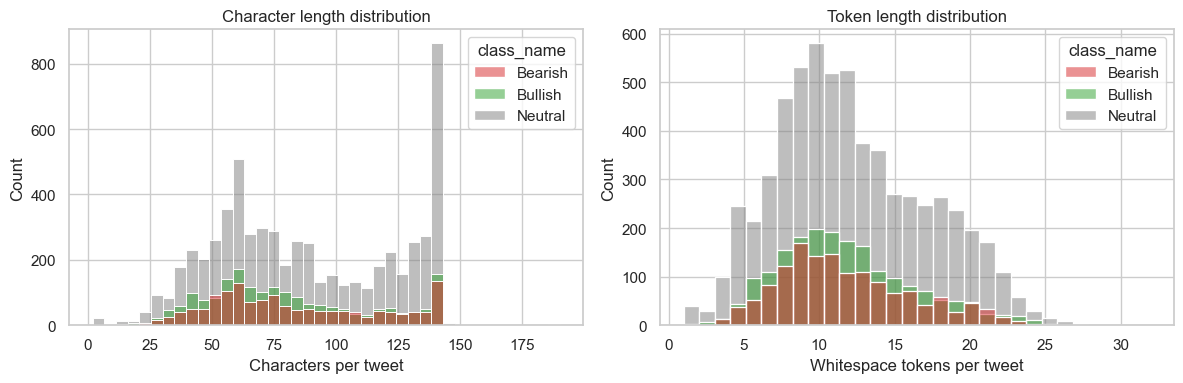

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_df = train.assign(class_name=train["label"].map(LABEL_NAMES))

sns.histplot(data=plot_df, x="char_len", hue="class_name",
             multiple="layer", bins=40, palette=LABEL_PALETTE, ax=axes[0])
axes[0].set_title("Character length distribution")
axes[0].set_xlabel("Characters per tweet")

sns.histplot(data=plot_df, x="token_len", hue="class_name",
             multiple="layer", bins=30, palette=LABEL_PALETTE, ax=axes[1])
axes[1].set_title("Token length distribution")
axes[1].set_xlabel("Whitespace tokens per tweet")

plt.tight_layout()
plt.savefig(OUT_DIR / "length_distributions.png")
plt.show()

## Word clouds + top-n words per class

In [12]:
URL_RE     = re.compile(r"https?://\S+")
MENTION_RE = re.compile(r"@\w+")
CASHTAG_RE = re.compile(r"\$[A-Za-z]+")
HASHTAG_RE = re.compile(r"#\w+")
NON_ALPHA  = re.compile(r"[^a-zA-Z\s]")


def clean_for_wordcloud(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = URL_RE.sub(" ", text)
    t = MENTION_RE.sub(" ", t)
    t = CASHTAG_RE.sub(" ", t)
    t = HASHTAG_RE.sub(" ", t)
    t = t.lower()
    t = NON_ALPHA.sub(" ", t)
    return " ".join(tok for tok in t.split() if tok not in STOPWORDS and len(tok) > 2)


train["clean"] = train["text"].apply(clean_for_wordcloud)
train[["text", "clean"]].head()

,text,clean
0,$BYND - JPMorgan reels in expectations on Beyo...,jpmorgan reels expectations beyond meat
1,$CCL $RCL - Nomura points to bookings weakness...,nomura points bookings weakness carnival royal...
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",cemex cut credit suisse morgan weak building o...
3,$ESS: BTIG Research cuts to Neutral https://t....,btig research cuts neutral
4,$FNKO - Funko slides after Piper Jaffray PT cu...,funko slides piper jaffray cut


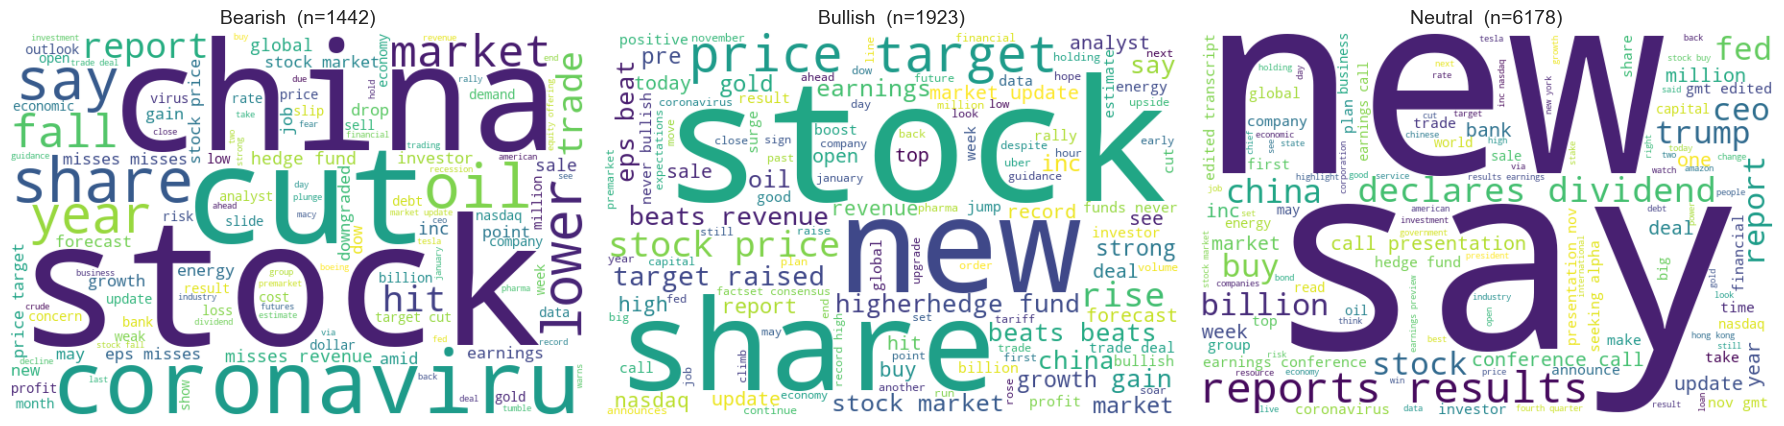

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (lbl, name) in zip(axes, LABEL_NAMES.items()):
    corpus = " ".join(train.loc[train["label"] == lbl, "clean"])
    wc = WordCloud(width=600, height=400, background_color="white",
                   max_words=120, random_state=42).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{name}  (n={(train['label'] == lbl).sum()})", fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "wordclouds_by_class.png")
plt.show()

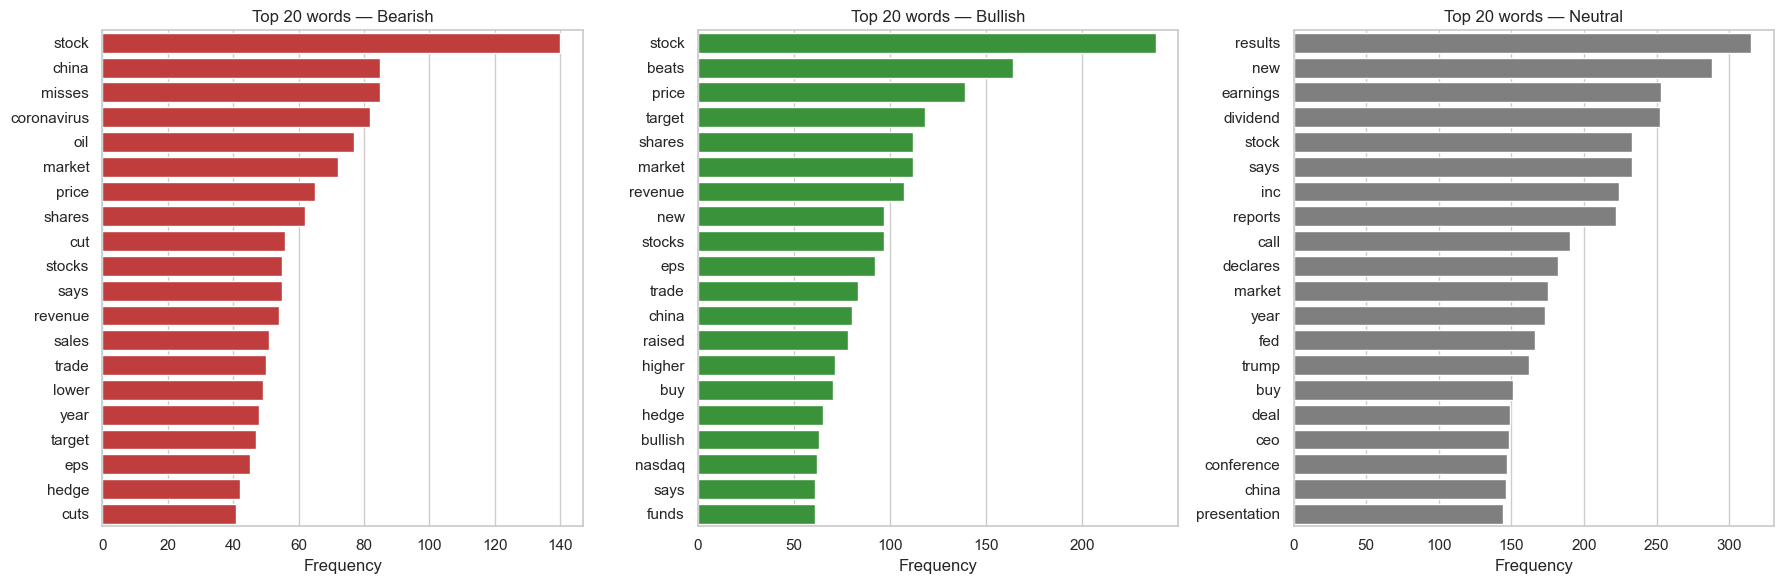

In [14]:
TOP_N = 20


def top_words(series: pd.Series, n: int = TOP_N) -> pd.DataFrame:
    counter: Counter = Counter()
    for txt in series:
        counter.update(txt.split())
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (lbl, name) in zip(axes, LABEL_NAMES.items()):
    df = top_words(train.loc[train["label"] == lbl, "clean"])
    sns.barplot(data=df, y="word", x="count", ax=ax, color=LABEL_PALETTE[name])
    ax.set_title(f"Top {TOP_N} words — {name}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "top_words_by_class.png")
plt.show()

## Hashtags / URLs / cashtags / mentions / duplicates / encoding

In [15]:
def count_pattern(text, pattern):
    if not isinstance(text, str):
        return 0
    return len(pattern.findall(text))


train["n_hashtags"] = train["text"].apply(lambda t: count_pattern(t, HASHTAG_RE))
train["n_urls"]     = train["text"].apply(lambda t: count_pattern(t, URL_RE))
train["n_cashtags"] = train["text"].apply(lambda t: count_pattern(t, CASHTAG_RE))
train["n_mentions"] = train["text"].apply(lambda t: count_pattern(t, MENTION_RE))

artefact_summary = train[["n_hashtags", "n_urls", "n_cashtags", "n_mentions"]].agg(["sum", "mean", "max"]).round(2)
print(artefact_summary)

print("\nProportion of tweets containing each artefact:")
for col in ["n_hashtags", "n_urls", "n_cashtags", "n_mentions"]:
    print(f"  {col}: {(train[col] > 0).mean()*100:.1f}%")

      n_hashtags   n_urls  n_cashtags  n_mentions
sum      2182.00  5095.00     2027.00      347.00
mean        0.23     0.53        0.21        0.04
max         7.00     3.00       23.00        8.00

Proportion of tweets containing each artefact:
  n_hashtags: 9.4%
  n_urls: 46.8%
  n_cashtags: 15.0%
  n_mentions: 3.1%


         n_hashtags  n_urls  n_cashtags  n_mentions
label                                              
Bearish       0.165   0.510       0.216       0.021
Bullish       0.158   0.438       0.341       0.017
Neutral       0.265   0.569       0.171       0.046


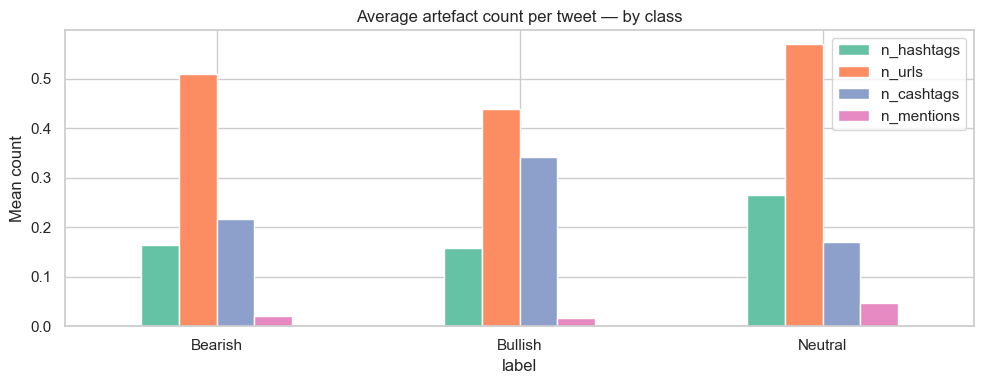

In [16]:
artefact_rates = (
    train.groupby("label")[["n_hashtags", "n_urls", "n_cashtags", "n_mentions"]]
    .mean()
    .round(3)
)
artefact_rates.index = artefact_rates.index.map(LABEL_NAMES)
print(artefact_rates)

ax = artefact_rates.plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_title("Average artefact count per tweet — by class")
ax.set_ylabel("Mean count")
plt.tight_layout()
plt.savefig(OUT_DIR / "artefact_rates_by_class.png")
plt.show()

In [17]:
def extract_all(series, pattern):
    items = []
    for t in series.dropna():
        items.extend(pattern.findall(t))
    return Counter(items)


print("Top 15 cashtags:", extract_all(train["text"], CASHTAG_RE).most_common(15))
print()
print("Top 15 hashtags:", extract_all(train["text"], HASHTAG_RE).most_common(15))

Top 15 cashtags: [('$SPY', 26), ('$COMDX', 23), ('$TSLA', 20), ('$SCANX', 16), ('$SUMRX', 13), ('$USO', 12), ('$MDCO', 11), ('$NVDA', 11), ('$ECONX', 11), ('$AAPL', 10), ('$UBER', 10), ('$AMZN', 10), ('$IWM', 10), ('$DIS', 9), ('$WIRES', 9)]

Top 15 hashtags: [('#MarketScreener', 477), ('#Stock', 379), ('#economy', 222), ('#markets', 81), ('#trading', 80), ('#finance', 80), ('#stocks', 72), ('#business', 71), ('#investing', 69), ('#stockmarket', 63), ('#WTI', 17), ('#LondonStockExchange', 13), ('#index', 12), ('#market', 10), ('#SP500', 8)]


In [18]:
n_exact_dup = train["text"].duplicated().sum()
n_ci_dup    = train["text"].str.lower().str.strip().duplicated().sum()
n_empty     = (train["text"].fillna("").str.strip() == "").sum()
print(f"train — exact duplicates: {n_exact_dup}")
print(f"train — case-insensitive + trimmed duplicates: {n_ci_dup}")
print(f"train — empty/whitespace rows: {n_empty}")

print("\nTest set:")
print(f"  exact dup: {test['text'].duplicated().sum()}")
print(f"  empty rows: {(test['text'].fillna('').str.strip() == '').sum()}")

train — exact duplicates: 0
train — case-insensitive + trimmed duplicates: 3
train — empty/whitespace rows: 0

Test set:
  exact dup: 0
  empty rows: 0


In [19]:
def has_non_ascii(text: str) -> bool:
    if not isinstance(text, str):
        return False
    return any(ord(c) > 127 for c in text)


n_non_ascii_train = train["text"].apply(has_non_ascii).sum()
n_non_ascii_test  = test["text"].apply(has_non_ascii).sum()
print(f"Non-ASCII tweets — train: {n_non_ascii_train} ({n_non_ascii_train/len(train)*100:.2f}%)")
print(f"Non-ASCII tweets — test : {n_non_ascii_test} ({n_non_ascii_test/len(test)*100:.2f}%)")

print("\nSample non-ASCII tweets:")
for txt in train.loc[train["text"].apply(has_non_ascii), "text"].head(5):
    print(" -", txt[:120])

Non-ASCII tweets — train: 2243 (23.50%)
Non-ASCII tweets — test : 585 (24.50%)

Sample non-ASCII tweets:
 - Downgrades 4/7: $MLND $MSGN $MTLS $O $OC $OVV $PEB $PK $PLYA $QEP $RHP $RPAI $SAIA $SDC $SHOP $SKY $SLG $SM $TWLO… https
 - Netflix downgraded to ‘underperform’ at Needham
 - Wells Fargo Downgrades Netflix $NFLX to Underperform but sees as a takeover target. NFLX could get acquired: NFLX i… htt
 - Activision, Take-Two charts look 'constructive' as Wells Fargo gets bullish on video game plays: Trader $ATVI $TTWO… htt
 - Morgan Stanley analyst Joseph Moore upgraded NVIDIA (NASDAQ: $NVDA) from Equalweight to Overweight with a price tar… htt


## Findings & decisions

| Topic | Observation | Decision |
|-------|-------------|----------|
| **Class balance** | See `class_distribution.png` — distribution is uneven (typically Bullish-dominant). | Use 
`class_weight='balanced'` or over/undersampling (handled in TM-015). |
| **Length** | Tweets are short and consistent across classes. | `max_length=64` for transformer tokenisation is sufficient. |
| **Cashtags ($AAPL …)** | Present in a meaningful fraction of tweets and carry domain signal. | **Keep** cashtags — strip `$`, preserve the ticker token. |
| **Hashtags (#bullish …)** | Carry sentiment in some cases. | **Keep** hashtag body — drop the `#`. |
| **URLs / mentions** | Add noise without sentiment value. | Replace with placeholder tokens in `preprocessing.py` (TM-008). |
| **Duplicates / empty rows** | Counts shown above. | If non-trivial, deduplicate **before** the train/val split (TM-007). |
| **Encoding** | Small % of non-ASCII characters; UTF-8 reads correctly. | No special handling beyond standard tokenisation. |